# FSA test: single-null vs double-null equilibria

Tests `saarelma_connor.fsa`, `calc_gradr`, and `plasma_surface_area_and_volume`
after the `_select_core_contour` fix (`src/solver.py`). Previously the *longest*
contour segment at each psi level was assumed to be the flux surface; on
double-null equilibria (SPARC, ARC) an open divertor-leg / SOL contour is often
longer than the closed core surface, which silently corrupted flux-surface
averages (it even produced negative $\langle|\nabla r|^2\rangle$) and the
enclosed-volume geometry (non-monotonic $V_{\rm plasma}$, sign-flipping
$dV/d\psi$, hence a sign-flipping Connor–Hastie $\alpha$ coefficient). The fix
selects the longest *closed* contour that *encloses the magnetic axis*.

Cases:
- **Single null:** DIII-D `g125729.03589` (Snyder HighPerfHMode database) — regression, behavior should be unchanged.
- **Double null:** SPARC PRD (`gSPARC_DN_PRD.geqdsk`, same inputs as `scan_free_param.py`).
- **Double null:** ARC baseline (`geqdsk-ARCv3a`, same inputs as `ARC.ipynb`).

Checks per equilibrium:
1. $\langle 1 \rangle = 1$ exactly (quadrature weights cancel).
2. $\langle \psi_N \rangle = \psi_N$ of each surface (contour points sit on the level set).
3. All surfaces in $0.02 < \psi_N < 0.98$ found (no NaN).
4. $\langle|\nabla r|^2\rangle$ finite, strictly positive, and smooth.
5. Cauchy–Schwarz: $\langle|\nabla r|^2\rangle \ge \langle|\nabla r|\rangle^2$.
6. Visual: selected contour vs the old longest-segment heuristic near the edge.

Volume/area checks (`plasma_surface_area_and_volume`), per equilibrium:
1. $V_{\rm plasma}$, $S_{\rm plasma}$ finite and strictly positive.
2. $V_{\rm plasma}$, $S_{\rm plasma}$ monotonically increasing in $\psi_N$.
3. $dV/d\psi_N$ single-signed (no sign flips inside the plasma).
4. $V_{\rm plasma}$ smooth (no order-of-magnitude point-to-point jumps).
5. Connor–Hastie equilibrium factor `_alpha_nodp_xinit` single-signed across the pedestal.

In [4]:
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

%matplotlib inline

HERE = Path.cwd()            # tests/model_logistics_tests
ROOT = HERE.parent.parent    # saarelma-conner-ped/
sys.path.insert(0, str(ROOT))

tokamaker_python_path = os.getenv('OFT_ROOTPATH')
if tokamaker_python_path is not None:
    sys.path.append(os.path.join(tokamaker_python_path, 'python'))

from src.solver import saarelma_connor

# Dummy free parameters: irrelevant for FSA / geometry, but required by the constructor.
FREE_PARAMS = dict(alpha_crit=1.0, C_KBM=1.0, De_chie_etg=1.0,
                   nFC_x0=1e16, ncx_x0_ratio=1.0)

# Single null: DIII-D case from the Snyder HighPerfHMode equilibria list
DIIID_G = Path('/mnt/homes_global/jal2351/software/sc_inputs/gHighPerfHMode/g125729.03589')
DIIID_P = Path('/mnt/homes_global/jal2351/software/sc_inputs/OMFITnc_HighPerfHMode/IDA_125729_3.55_3.65_.cdf')

# Double null: SPARC PRD (reuse the loaders from scan_free_param.py)
SPARC_DIR = ROOT / 'examples' / 'device_prediction' / 'SPARC'
sys.path.insert(0, str(SPARC_DIR))

# Double null: ARC baseline (same inputs as ARC.ipynb)
ARC_DIR = ROOT / 'examples' / 'device_prediction' / 'ARC'
ARC_G = ARC_DIR / 'geqdsk-ARCv3a'

models = {}      # label -> built model
all_checks = {}  # label -> {check name: (ok, info)}

In [5]:
# Test helpers

def run_fsa_checks(m, label, psi_window=(0.02, 0.98), smooth_tol=1.0):
    """Quantitative checks of fsa() and calc_gradr() for one equilibrium.

    Returns {check name: (passed, info string)} and prints a PASS/FAIL table.
    ``psi_window`` avoids the axis and the separatrix, where fsa()
    intentionally skips surfaces (psi <= 0.01 or >= 0.99) and calc_gradr
    fills from neighbours.
    """
    psi = m.psi_N_pres
    win = (psi > psi_window[0]) & (psi < psi_window[1])
    checks = {}

    # 1) <1> = 1: numerator and denominator integrals are identical.
    fsa_one = m.fsa(np.ones_like(m.psi_RZ_N), flux_surfaces='psi_N_pres')
    err_one = np.nanmax(np.abs(fsa_one[win] - 1.0))
    checks['<1> == 1'] = (err_one < 1e-6, f'max err = {err_one:.2e}')

    # 2) <psi_N> = psi_N: contour points lie on the level set, so the
    #    average of psi_N over the surface must return the level itself.
    #    Tolerance 2e-3: matplotlib contour vertices are *linear*
    #    interpolants of the psi grid while the FSA evaluates a cubic
    #    spline off-node, an O(h^2) discretization error largest near
    #    the axis where the surface is small relative to the grid.
    fsa_psi = m.fsa(m.psi_RZ_N, flux_surfaces='psi_N_pres')
    err_psi = np.nanmax(np.abs(fsa_psi[win] - psi[win]))
    checks['<psi_N> == psi_N'] = (err_psi < 2e-3, f'max err = {err_psi:.2e}')

    # 3) Every surface in the window must be found (closed contour around axis).
    n_nan = int(np.isnan(fsa_one[win]).sum())
    checks['all surfaces found'] = (n_nan == 0, f'{n_nan} NaN of {int(win.sum())} surfaces')

    # 4) <|grad r|^2> from calc_gradr: finite and strictly positive.
    g1, g2 = m.gradr_fsa, m.gradr2_fsa
    checks['<|grad r|^2> finite'] = (bool(np.all(np.isfinite(g2))), '')
    checks['<|grad r|^2> > 0'] = (bool(np.all(g2 > 0)),
                                  f'min = {np.nanmin(g2):.3e}')

    # 5) Cauchy-Schwarz with the R^2 dtheta weight: <g^2> >= <g>^2.
    cs_ok = bool(np.all(g2[win] >= (g1[win] ** 2) * (1.0 - 1e-6)))
    checks['<g^2> >= <g>^2 (Cauchy-Schwarz)'] = (cs_ok, '')

    # 6) Smoothness: the old bug produced order-of-magnitude point-to-point
    #    jumps; require max |d log <g^2>| below smooth_tol.
    jump = float(np.max(np.abs(np.diff(np.log(g2[win])))))
    checks['<|grad r|^2> smooth'] = (jump < smooth_tol,
                                     f'max |dlog| = {jump:.2f} (tol {smooth_tol})')

    print(f'--- {label} ---')
    for name, (ok, info) in checks.items():
        print(f'  {"PASS" if ok else "FAIL":4s}  {name:35s} {info}')
    return checks


def run_volume_checks(m, label, psi_window=(0.02, 0.98), smooth_tol=1.0):
    """Quantitative checks of plasma_surface_area_and_volume() for one
    equilibrium.

    ``plasma_surface_area_and_volume`` used the same "longest contour
    segment" heuristic that the FSA bug did, so on double-null equilibria
    (SPARC, ARC) it selected open divertor-leg / SOL contours and produced
    non-monotonic ``V_plasma``, a sign-flipping ``dV/dpsi``, and hence a
    sign-flipping Connor-Hastie equilibrium factor ``_alpha_nodp_xinit``
    (which feeds alpha and the KBM gate).  These checks guard the
    ``_select_core_contour`` fix.  Returns {check name: (passed, info)}.
    """
    psi = m.psi_N_pres
    win = (psi > psi_window[0]) & (psi < psi_window[1])
    V, S = m.V_plasma, m.S_plasma
    checks = {}

    # 1) Finite and strictly positive enclosed volume / surface area.
    checks['V_plasma finite & > 0'] = (
        bool(np.all(np.isfinite(V)) and np.all(V > 0)),
        f'min = {np.nanmin(V):.3e}')
    checks['S_plasma finite & > 0'] = (
        bool(np.all(np.isfinite(S)) and np.all(S > 0)),
        f'min = {np.nanmin(S):.3e}')

    # 2) Enclosed volume / area must grow monotonically outward (psi_N is
    #    ascending 0 -> 1).  The old bug produced decreasing steps where an
    #    open contour was picked.
    n_bad_V = int((np.diff(V) <= 0).sum())
    n_bad_S = int((np.diff(S) <= 0).sum())
    checks['V_plasma monotonic in psi_N'] = (n_bad_V == 0,
                                             f'{n_bad_V} non-increasing steps')
    checks['S_plasma monotonic in psi_N'] = (n_bad_S == 0,
                                             f'{n_bad_S} non-increasing steps')

    # 3) dV/dpsi_N must stay single-signed (strictly positive since psi_N
    #    ascends).  The bug flipped its sign inside the pedestal, which is
    #    exactly what corrupts the Connor-Hastie alpha.
    dVdpsiN = np.gradient(V, psi)
    n_flip = int((dVdpsiN[win] <= 0).sum())
    checks['dV/dpsi_N single-signed'] = (n_flip == 0,
                                         f'{n_flip} sign flips in window')

    # 4) Smoothness: no order-of-magnitude point-to-point jumps in V.
    jump = float(np.max(np.abs(np.diff(np.log(V[win])))))
    checks['V_plasma smooth'] = (jump < smooth_tol,
                                 f'max |dlog| = {jump:.2f} (tol {smooth_tol})')

    # 5) Downstream physics payoff: the Connor-Hastie equilibrium factor
    #    _alpha_nodp_xinit (proportional to dV/dpsi) must not flip sign in
    #    the pedestal (psi_N >= 0.85).  setup_solver_grids() populates it.
    m.setup_solver_grids()
    a = m._alpha_nodp_xinit
    ped = psi >= 0.85
    sign_changes = int((np.diff(np.sign(a[ped])) != 0).sum())
    checks['alpha coeff single-signed (pedestal)'] = (
        sign_changes == 0, f'{sign_changes} sign changes')

    print(f'--- {label} (volume/area) ---')
    for name, (ok, info) in checks.items():
        print(f'  {"PASS" if ok else "FAIL":4s}  {name:38s} {info}')
    return checks


def _psi_contour_segments(m, psi_N_level):
    """All matplotlib contour segments of psi_RZ_N at one level."""
    fig, ax = plt.subplots()
    cs = ax.contour(m.rgrid, m.zgrid, m.psi_RZ_N, levels=[psi_N_level])
    plt.close(fig)
    return cs.allsegs[0]


def plot_contour_selection(m, label, psi_levels=(0.85, 0.95, 0.99)):
    """Show every contour segment (grey), the old longest-segment choice
    (dotted orange) and the new closed-around-axis choice (red)."""
    R_axis, Z_axis = m.eq['raxis'], m.eq['zaxis']
    fig, axes = plt.subplots(1, len(psi_levels),
                             figsize=(3.8 * len(psi_levels), 6.5),
                             sharex=True, sharey=True)
    n_changed = 0
    for ax, pn in zip(np.atleast_1d(axes), psi_levels):
        segs = _psi_contour_segments(m, pn)
        sel = m._select_core_contour(segs, R_axis, Z_axis)
        longest = max(segs, key=len) if len(segs) else None
        for s in segs:
            ax.plot(s[:, 0], s[:, 1], color='0.8', lw=1)
        if longest is not None:
            ax.plot(longest[:, 0], longest[:, 1], color='tab:orange', lw=2.5,
                    ls=':', label='old: longest segment')
        if sel is not None:
            ax.plot(sel[:, 0], sel[:, 1], color='tab:red', lw=1.6,
                    label='new: closed, encloses axis')
            if longest is not None and (len(sel) != len(longest)
                                        or not np.allclose(sel, longest)):
                n_changed += 1
        ax.plot(R_axis, Z_axis, 'k+', ms=12, mew=2, label='magnetic axis')
        ax.set_title(fr'$\psi_N$ = {pn}')
        ax.set_xlabel('R (m)')
        ax.set_aspect('equal')
    np.atleast_1d(axes)[0].set_ylabel('Z (m)')
    np.atleast_1d(axes)[0].legend(fontsize=8, loc='lower left')
    fig.suptitle(f'{label}: flux-surface contour selection')
    plt.tight_layout()
    plt.show()
    print(f'{label}: new selection differs from old longest-segment heuristic '
          f'at {n_changed}/{len(psi_levels)} plotted levels')

--- DIII-D 125729 (single null) ---
  PASS  <1> == 1                            max err = 1.89e-15
  PASS  <psi_N> == psi_N                    max err = 9.15e-04
  PASS  all surfaces found                  0 NaN of 61 surfaces
  PASS  <|grad r|^2> finite                 
  PASS  <|grad r|^2> > 0                    min = 4.184e-02
  PASS  <g^2> >= <g>^2 (Cauchy-Schwarz)     
  PASS  <|grad r|^2> smooth                 max |dlog| = 0.05 (tol 1.0)
--- DIII-D 125729 (single null) (volume/area) ---
  PASS  V_plasma finite & > 0                  min = 1.278e-01
  PASS  S_plasma finite & > 0                  min = 4.309e+00
  PASS  V_plasma monotonic in psi_N            0 non-increasing steps
  PASS  S_plasma monotonic in psi_N            0 non-increasing steps
  PASS  dV/dpsi_N single-signed                0 sign flips in window
  PASS  V_plasma smooth                        max |dlog| = 0.43 (tol 1.0)
  PASS  alpha coeff single-signed (pedestal)   0 sign changes


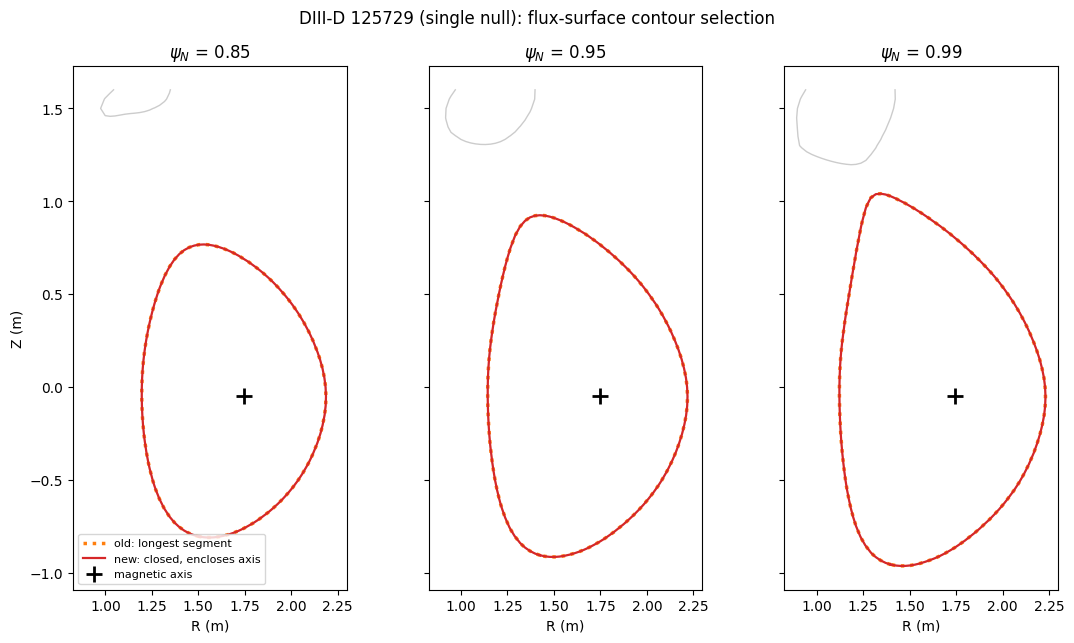

DIII-D 125729 (single null): new selection differs from old longest-segment heuristic at 0/3 plotted levels


In [6]:
# Single null: DIII-D 125729 (Snyder HighPerfHMode database).
# Regression case: the closed core contour was already the longest segment on
# most levels here, so the fix should leave this equilibrium unchanged.
label = 'DIII-D 125729 (single null)'
m_d3d = saarelma_connor(
    P_tot_e=5e6, species='D', Z_i=1,
    mhd_fp=str(DIIID_G), kprof_fp=str(DIIID_P), kprof_loc='OMFITnc',
    verbose=False, **FREE_PARAMS,
)
models[label] = m_d3d
all_checks[label] = run_fsa_checks(m_d3d, label)
all_checks[label].update(run_volume_checks(m_d3d, label))
plot_contour_selection(m_d3d, label)

Using existing gEQDSK: /mnt/homes_global/jal2351/software/saarelma-conner-ped/examples/device_prediction/SPARC/gSPARC_DN_PRD.geqdsk
Loaded 6 - cgyro_20221013.txt (cgyro): 201 profile points
POPCON: P_ohmic=1.70 MW, P_RF=11.10 MW, P_tot_e=6.40 MW, Zeff=1.5
--- SPARC PRD (double null) ---
  PASS  <1> == 1                            max err = 5.33e-15
  PASS  <psi_N> == psi_N                    max err = 6.90e-04
  PASS  all surfaces found                  0 NaN of 123 surfaces
  PASS  <|grad r|^2> finite                 
  PASS  <|grad r|^2> > 0                    min = 2.921e+00
  PASS  <g^2> >= <g>^2 (Cauchy-Schwarz)     
  PASS  <|grad r|^2> smooth                 max |dlog| = 0.02 (tol 1.0)
--- SPARC PRD (double null) (volume/area) ---
  PASS  V_plasma finite & > 0                  min = 9.285e-02
  PASS  S_plasma finite & > 0                  min = 3.862e+00
  PASS  V_plasma monotonic in psi_N            0 non-increasing steps
  PASS  S_plasma monotonic in psi_N            0 non-inc

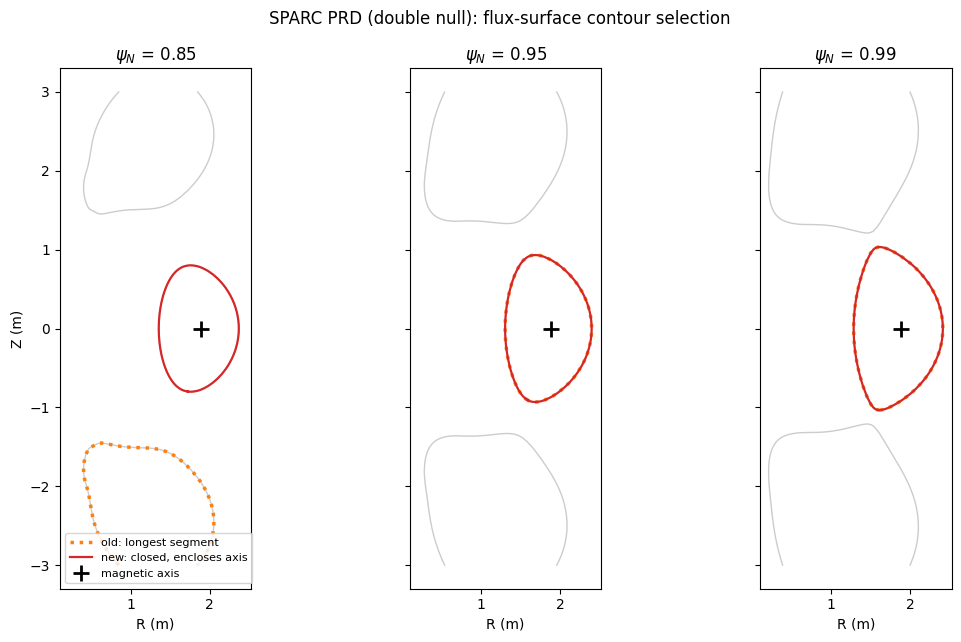

SPARC PRD (double null): new selection differs from old longest-segment heuristic at 1/3 plotted levels


In [7]:
# Double null: SPARC PRD, same inputs as scan_free_param.py.
# This is the equilibrium where the old longest-segment heuristic picked open
# divertor-leg contours and produced negative <|grad r|^2> in the pedestal.
from scan_free_param import load_sparc_inputs

label = 'SPARC PRD (double null)'
mhd_fp_sparc, manual_profs_sparc, P_tot_e_sparc, Zeff_sparc = load_sparc_inputs()
m_sparc = saarelma_connor(
    P_tot_e=P_tot_e_sparc, species='D-T', Z_i=Zeff_sparc,
    mhd_fp=mhd_fp_sparc, kprof_loc='manual psi_N grid',
    manual_profs=manual_profs_sparc, x_method='radas',
    verbose=False, **FREE_PARAMS,
)
models[label] = m_sparc
all_checks[label] = run_fsa_checks(m_sparc, label)
all_checks[label].update(run_volume_checks(m_sparc, label))
plot_contour_selection(m_sparc, label)

--- ARC v3a (double null) ---
  PASS  <1> == 1                            max err = 1.29e-12
  PASS  <psi_N> == psi_N                    max err = 7.16e-04
  PASS  all surfaces found                  0 NaN of 123 surfaces
  PASS  <|grad r|^2> finite                 
  PASS  <|grad r|^2> > 0                    min = 3.932e+01
  PASS  <g^2> >= <g>^2 (Cauchy-Schwarz)     
  PASS  <|grad r|^2> smooth                 max |dlog| = 0.01 (tol 1.0)
--- ARC v3a (double null) (volume/area) ---
  PASS  V_plasma finite & > 0                  min = 8.651e-01
  PASS  S_plasma finite & > 0                  min = 1.844e+01
  PASS  V_plasma monotonic in psi_N            0 non-increasing steps
  PASS  S_plasma monotonic in psi_N            0 non-increasing steps
  PASS  dV/dpsi_N single-signed                0 sign flips in window
  PASS  V_plasma smooth                        max |dlog| = 0.30 (tol 1.0)
  PASS  alpha coeff single-signed (pedestal)   0 sign changes


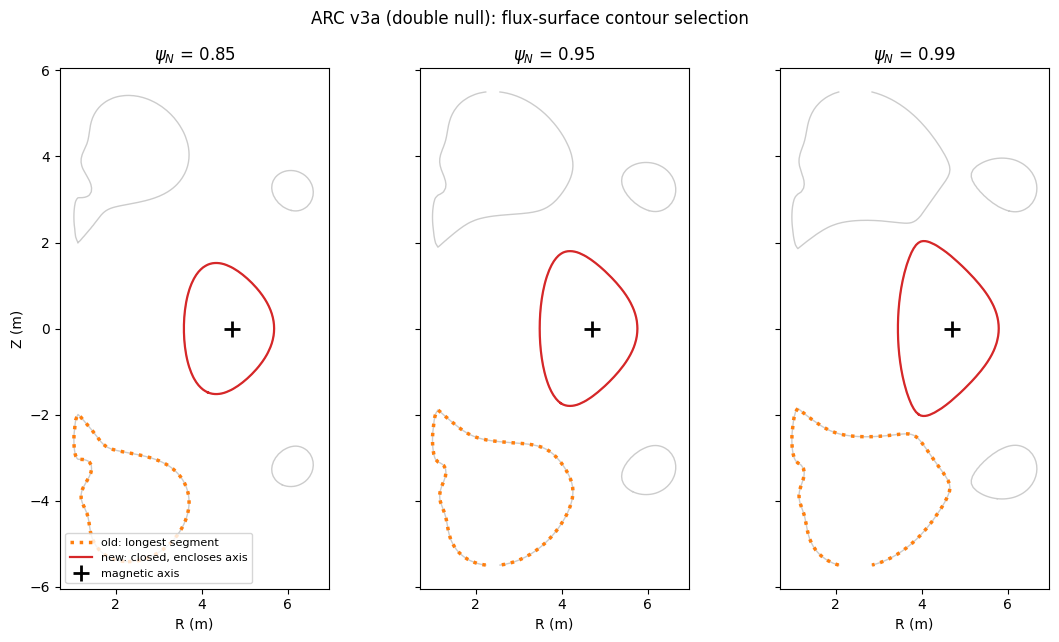

ARC v3a (double null): new selection differs from old longest-segment heuristic at 3/3 plotted levels


In [8]:
# Double null: ARC baseline, same inputs as ARC.ipynb
# (geqdsk-ARCv3a + profiles digitized from Howard et al. 2026 Fig. 4).

def load_digitized_profile(filepath):
    """Parse an ARC_*_extracted.txt Web Plot Digitizer export -> (rho, values)."""
    rows, quantity = [], None
    for line in Path(filepath).read_text().splitlines():
        line = line.strip()
        if not line:
            continue
        if line.lower().startswith('rho,'):
            quantity = 'ne' if 'ne' in line.lower() else 'Te'
            continue
        parts = [p.strip() for p in line.split(',')]
        if quantity is not None and len(parts) == 2:
            try:
                rows.append((float(parts[0]), float(parts[1])))
            except ValueError:
                pass
    data = np.array(sorted(rows))
    return data[:, 0], data[:, 1]


rho_ne_arc, ne_arc = load_digitized_profile(ARC_DIR / 'ARC_ne_extracted.txt')  # 10^20 m^-3
rho_Te_arc, Te_arc = load_digitized_profile(ARC_DIR / 'ARC_Te_extracted.txt')  # keV
manual_profs_arc = {
    'ne': ne_arc, 'rho_ne': rho_ne_arc,
    'Te': Te_arc, 'rho_Te': rho_Te_arc,
}

label = 'ARC v3a (double null)'
m_arc = saarelma_connor(
    P_tot_e=(21.5 + 0.8 + 227) * 0.5 * 1e6,  # table 4 of Hillesheim et al. 2026
    species='D-T', Z_i=1,
    mhd_fp=str(ARC_G), kprof_loc='manual rho grid',
    manual_profs=manual_profs_arc, x_method='radas',
    verbose=False, **FREE_PARAMS,
)
models[label] = m_arc
all_checks[label] = run_fsa_checks(m_arc, label)
all_checks[label].update(run_volume_checks(m_arc, label))
plot_contour_selection(m_arc, label)

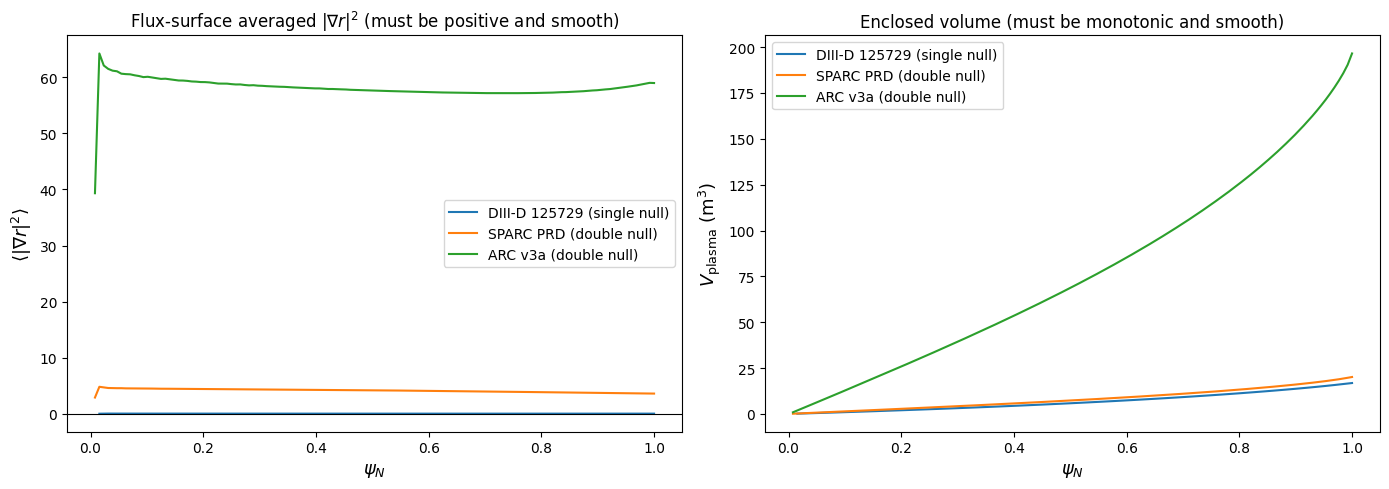

All FSA checks passed for: DIII-D 125729 (single null), SPARC PRD (double null), ARC v3a (double null)


In [9]:
# Summary: <|grad r|^2> and V_plasma profiles for all three equilibria + verdict.
fig, (ax, ax2) = plt.subplots(1, 2, figsize=(14, 5))
for label, m in models.items():
    ax.plot(m.psi_N_pres, m.gradr2_fsa, label=label)
    ax2.plot(m.psi_N_pres, m.V_plasma, label=label)
ax.set_xlabel(r'$\psi_N$', fontsize=13)
ax.set_ylabel(r'$\langle|\nabla r|^2\rangle$', fontsize=13)
ax.axhline(0.0, color='k', lw=0.8)
ax.legend(fontsize=10)
ax.set_title('Flux-surface averaged $|\\nabla r|^2$ (must be positive and smooth)')

ax2.set_xlabel(r'$\psi_N$', fontsize=13)
ax2.set_ylabel(r'$V_{\rm plasma}$ (m$^3$)', fontsize=13)
ax2.legend(fontsize=10)
ax2.set_title('Enclosed volume (must be monotonic and smooth)')
plt.tight_layout()
plt.show()

failed = [(label, name)
          for label, checks in all_checks.items()
          for name, (ok, _) in checks.items() if not ok]
if failed:
    for label, name in failed:
        print(f'FAILED: [{label}] {name}')
assert not failed, f'{len(failed)} FSA check(s) failed: {failed}'
print(f'All FSA checks passed for: {", ".join(all_checks)}')

In [13]:
m_d3d = saarelma_connor(
    P_tot_e=5e6, species='D', Z_i=1,
    mhd_fp=str(DIIID_G), kprof_fp=str(DIIID_P), kprof_loc='OMFITnc',
    verbose=False, **FREE_PARAMS,
)
m_sparc = saarelma_connor(
    P_tot_e=P_tot_e_sparc, species='D-T', Z_i=Zeff_sparc,
    mhd_fp=mhd_fp_sparc, kprof_loc='manual psi_N grid',
    manual_profs=manual_profs_sparc, x_method='radas',
    verbose=False, **FREE_PARAMS,
)

V_sparc, S_sparc = m_sparc.V_plasma, m_sparc.S_plasma
V_d3d, S_d3d = m_d3d.V_plasma, m_d3d.S_plasma

print('DIII-D SA and V')
print(S_d3d[-1])
print(V_d3d[-1])
print('\n')
print('SPARC SA and V')
print(S_sparc[-1])
print(V_sparc[-1])


DIII-D SA and V
50.58375082554979
16.819388906441507


SPARC SA and V
58.54018129922306
20.10753881548506
